In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

print("Environment ready 🚀")

Environment ready 🚀


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("House_price.csv")

df.head()

,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (999, 6)

Columns:
['Avg. Area Income', 'House Age', 'Number of Rooms', 'Number of Bedrooms', 'Area Population', 'Price']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Avg. Area Income    999 non-null    float64
 1   House Age           999 non-null    float64
 2   Number of Rooms     999 non-null    float64
 3   Number of Bedrooms  999 non-null    float64
 4   Area Population     999 non-null    float64
 5   Price               999 non-null    float64
dtypes: float64(6)
memory usage: 47.0 KB


In [5]:
df.describe()

,Avg. Area Income,House Age,Number of Rooms,Number of Bedrooms,Area Population,Price
count,999.000000,999.000000,999.000000,999.000000,999.000000,9.990000e+02
mean,68783.805627,6.058283,7.016825,3.972973,35849.447580,1.249194e+06
std,10642.485432,0.988609,0.997815,1.234513,9745.900912,3.502090e+05
min,17796.631190,3.278228,3.236194,2.000000,172.610686,1.520719e+05
25%,61789.040515,5.407817,6.353208,3.140000,29136.252095,1.019847e+06
50%,68864.282300,6.043693,7.058765,4.040000,35991.720640,1.242979e+06
75%,75863.942790,6.766865,7.680286,4.500000,42733.057115,1.474933e+06
max,107701.748400,8.764786,9.710217,6.500000,69575.449460,2.469066e+06


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Avg. Area Income      0
House Age             0
Number of Rooms       0
Number of Bedrooms    0
Area Population       0
Price                 0
dtype: int64

Duplicate rows: 0


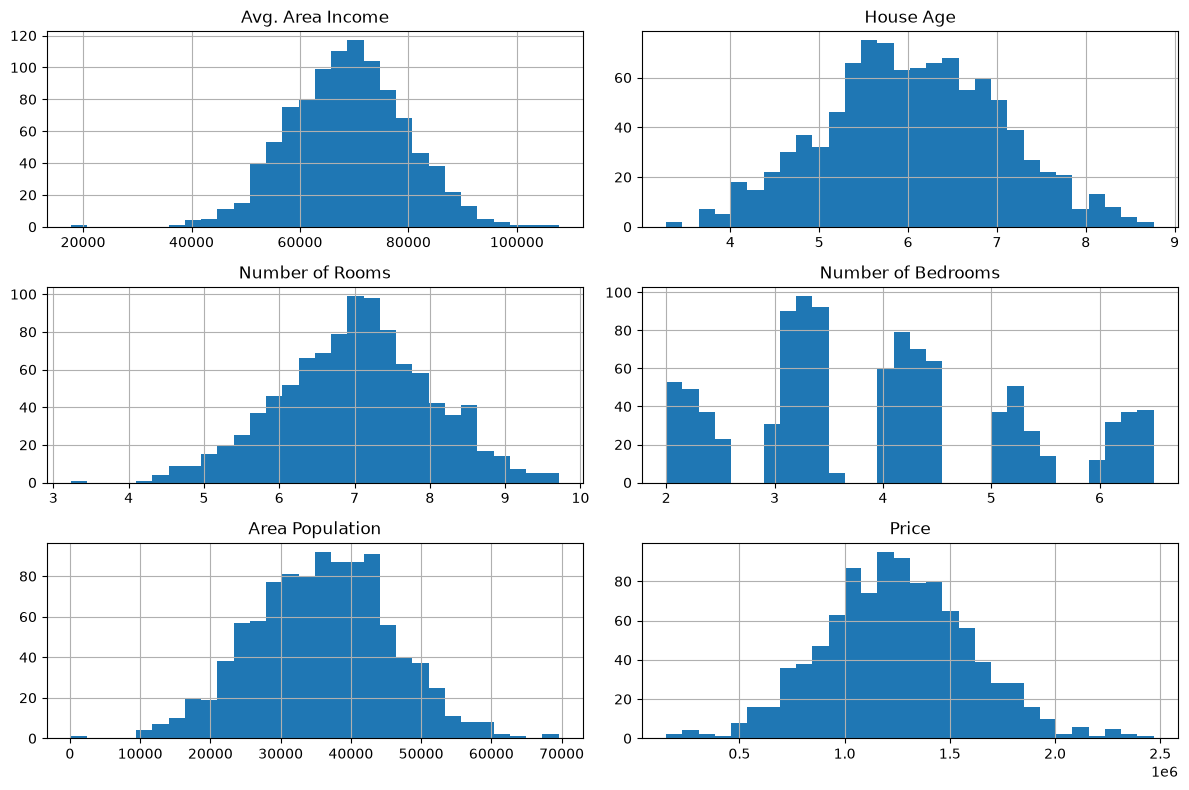

In [7]:
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

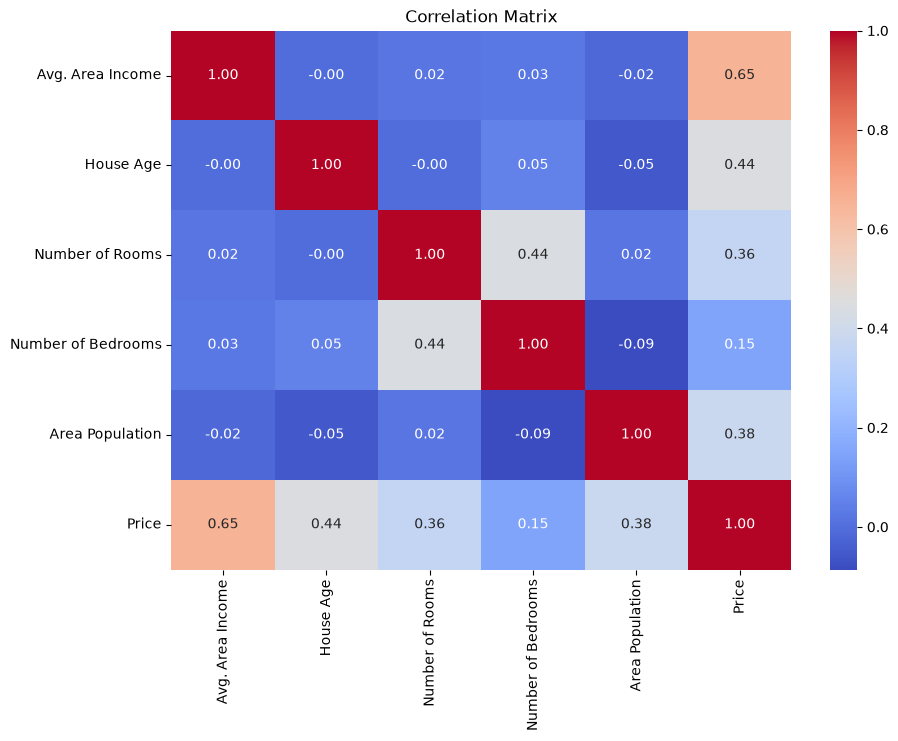

In [8]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

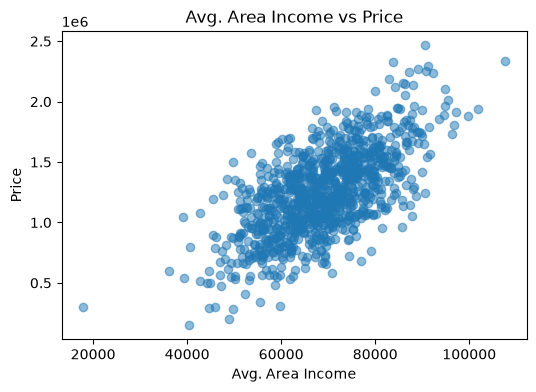

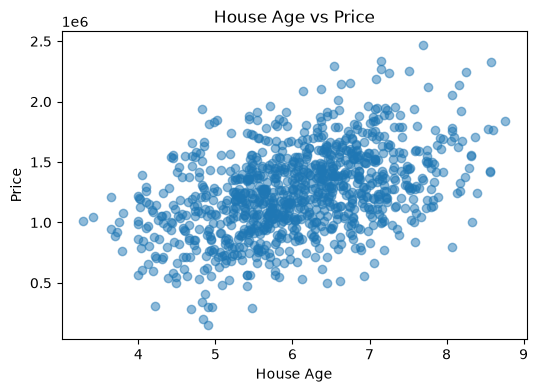

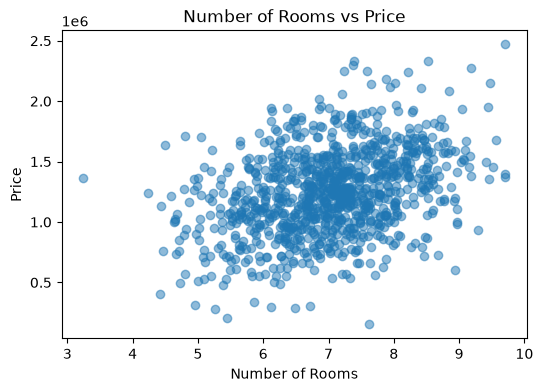

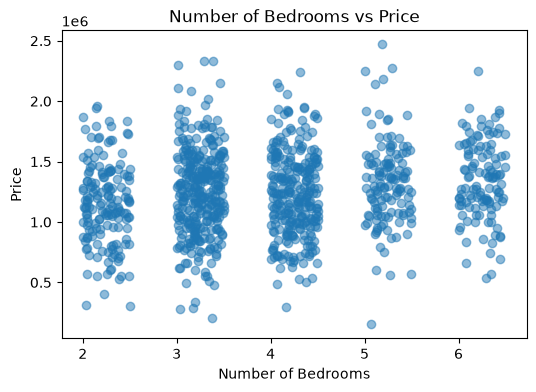

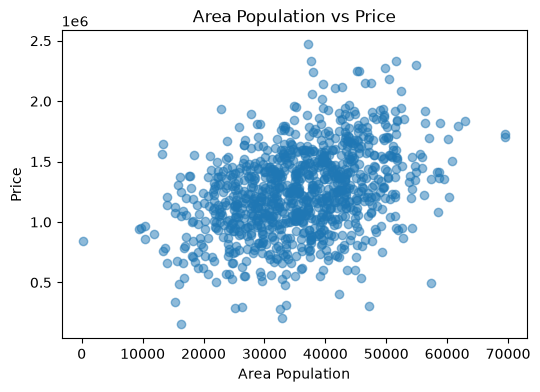

In [9]:
features = [
    "Avg. Area Income",
    "House Age",
    "Number of Rooms",
    "Number of Bedrooms",
    "Area Population"
]

for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature], df["Price"], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price")
    plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = [
    "Avg. Area Income",
    "House Age",
    "Number of Rooms",
    "Number of Bedrooms",
    "Area Population"
]

X = df[features]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 799
Testing samples : 200


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline Model")
print("----------------")
print("RMSE:", rmse)
print("R²  :", r2)

Baseline Model
----------------
RMSE: 100807.47379422124
R²  : 0.9163965747047242


In [13]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Avg. Area Income,21.934054
1,House Age,165890.458627
2,Number of Rooms,122831.101906
3,Number of Bedrooms,-3732.298158
4,Area Population,14.776010


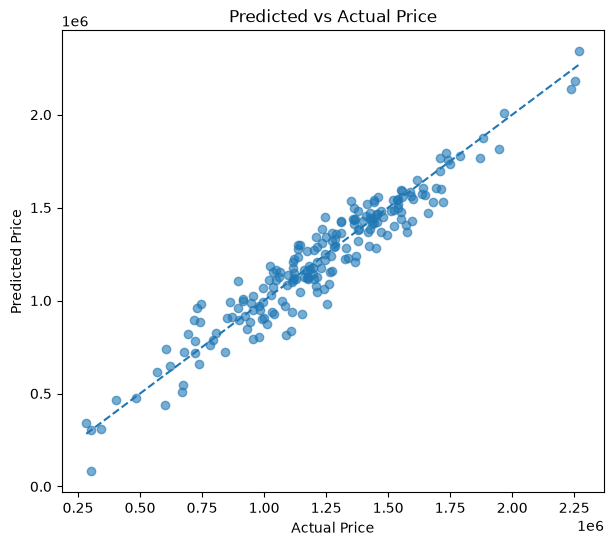

In [14]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")

plt.show()

In [15]:
def test_model(features):
    X_train_f = X_train[features]
    X_test_f = X_test[features]

    m = LinearRegression()
    m.fit(X_train_f, y_train)

    pred = m.predict(X_test_f)

    return r2_score(y_test, pred), np.sqrt(mean_squared_error(y_test, pred))


feature_sets = {
    "All features": features,
    "Without Bedrooms": [
        "Avg. Area Income",
        "House Age",
        "Number of Rooms",
        "Area Population"
    ],
    "Income + Age + Rooms": [
        "Avg. Area Income",
        "House Age",
        "Number of Rooms"
    ],
    "Income + Age + Population": [
        "Avg. Area Income",
        "House Age",
        "Area Population"
    ]
}

for name, feats in feature_sets.items():
    r2, rmse = test_model(feats)
    print(f"{name:25} R² = {r2:.4f} | RMSE = {rmse:,.2f}")

All features              R² = 0.9164 | RMSE = 100,807.47
Without Bedrooms          R² = 0.9163 | RMSE = 100,884.67
Income + Age + Rooms      R² = 0.7469 | RMSE = 175,413.18
Income + Age + Population R² = 0.8077 | RMSE = 152,886.91


In [16]:
train_fe = X_train.copy()
test_fe = X_test.copy()

for df_fe in [train_fe, test_fe]:
    df_fe["Income_x_Population"] = (
        df_fe["Avg. Area Income"] * df_fe["Area Population"]
    )

    df_fe["Income_x_Rooms"] = (
        df_fe["Avg. Area Income"] * df_fe["Number of Rooms"]
    )

    df_fe["Rooms_x_Age"] = (
        df_fe["Number of Rooms"] * df_fe["House Age"]
    )

    df_fe["Population_x_Rooms"] = (
        df_fe["Area Population"] * df_fe["Number of Rooms"]
    )

    df_fe["Income_per_Population"] = (
        df_fe["Avg. Area Income"] / df_fe["Area Population"]
    )

    df_fe["Rooms_per_Bedroom"] = (
        df_fe["Number of Rooms"] / df_fe["Number of Bedrooms"]
    )

In [17]:
base_features = features.copy()

new_features = [
    "Income_x_Population",
    "Income_x_Rooms",
    "Rooms_x_Age",
    "Population_x_Rooms",
    "Income_per_Population",
    "Rooms_per_Bedroom"
]

for new_feature in new_features:
    test_features = base_features + [new_feature]

    model_fe = LinearRegression()
    model_fe.fit(train_fe[test_features], y_train)

    pred_fe = model_fe.predict(test_fe[test_features])

    r2 = r2_score(y_test, pred_fe)
    rmse = np.sqrt(mean_squared_error(y_test, pred_fe))

    print(f"{new_feature:25} R² = {r2:.4f} | RMSE = {rmse:,.2f}")

Income_x_Population       R² = 0.5887 | RMSE = 223,588.25
Income_x_Rooms            R² = 0.9164 | RMSE = 100,792.73
Rooms_x_Age               R² = 0.9164 | RMSE = 100,807.32
Population_x_Rooms        R² = 0.9165 | RMSE = 100,742.48
Income_per_Population     R² = 0.9165 | RMSE = 100,764.40
Rooms_per_Bedroom         R² = 0.9164 | RMSE = 100,825.38


In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly2_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly2_model.fit(X_train, y_train)

poly2_pred = poly2_model.predict(X_test)

poly2_r2 = r2_score(y_test, poly2_pred)
poly2_rmse = np.sqrt(mean_squared_error(y_test, poly2_pred))

print("Polynomial Degree 2")
print("-------------------")
print("R²  :", round(poly2_r2, 4))
print("RMSE:", round(poly2_rmse, 2))

Polynomial Degree 2
-------------------
R²  : 0.9099
RMSE: 104641.37


In [19]:
for degree in [1, 2, 3]:
    model_poly = Pipeline([
        ("poly", PolynomialFeatures(
            degree=degree,
            include_bias=False
        )),
        ("linear", LinearRegression())
    ])

    model_poly.fit(X_train, y_train)
    pred = model_poly.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(
        f"Degree {degree} | "
        f"R² = {r2:.4f} | "
        f"RMSE = {rmse:,.2f}"
    )

Degree 1 | R² = 0.9164 | RMSE = 100,807.47
Degree 2 | R² = 0.9099 | RMSE = 104,641.37
Degree 3 | R² = 0.8876 | RMSE = 116,868.54


In [20]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100, 1000]

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5
)

ridge_cv.fit(X_train, y_train)

ridge_pred = ridge_cv.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Best alpha:", ridge_cv.alpha_)
print("R²  :", round(ridge_r2, 4))
print("RMSE:", round(ridge_rmse, 2))

Best alpha: 1.0
R²  : 0.9164
RMSE: 100810.38


In [21]:
from sklearn.linear_model import Ridge

for alpha in [0, 0.01, 0.1, 1, 10, 100, 1000]:
    
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    
    pred = ridge.predict(X_test)
    
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    print(
        f"alpha={alpha:<7} "
        f"R²={r2:.4f} "
        f"RMSE={rmse:,.2f}"
    )

alpha=0       R²=0.9164 RMSE=100,807.47
alpha=0.01    R²=0.9164 RMSE=100,807.50
alpha=0.1     R²=0.9164 RMSE=100,807.73
alpha=1       R²=0.9164 RMSE=100,810.38
alpha=10      R²=0.9163 RMSE=100,868.78
alpha=100     R²=0.9114 RMSE=103,796.04
alpha=1000    R²=0.8132 RMSE=150,688.48


In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Fold R² scores:", np.round(cv_scores, 4))
print("Mean CV R²    :", round(cv_scores.mean(), 4))
print("Std CV R²     :", round(cv_scores.std(), 4))

Fold R² scores: [0.9246 0.9174 0.9158 0.9075 0.9202]
Mean CV R²    : 0.9171
Std CV R²     : 0.0056


In [23]:
print("Test R²:", round(r2, 4))
print("CV R²  :", round(cv_scores.mean(), 4))

Test R²: 0.8132
CV R²  : 0.9171


In [24]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_test_r2 = r2_score(y_test, linear_pred)
linear_test_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

print("Linear Regression")
print("-----------------")
print("Test R² :", round(linear_test_r2, 4))
print("Test RMSE:", round(linear_test_rmse, 2))
print("Mean CV R²:", round(cv_scores.mean(), 4))
print("CV Std    :", round(cv_scores.std(), 4))

Linear Regression
-----------------
Test R² : 0.9164
Test RMSE: 100807.47
Mean CV R²: 0.9171
CV Std    : 0.0056


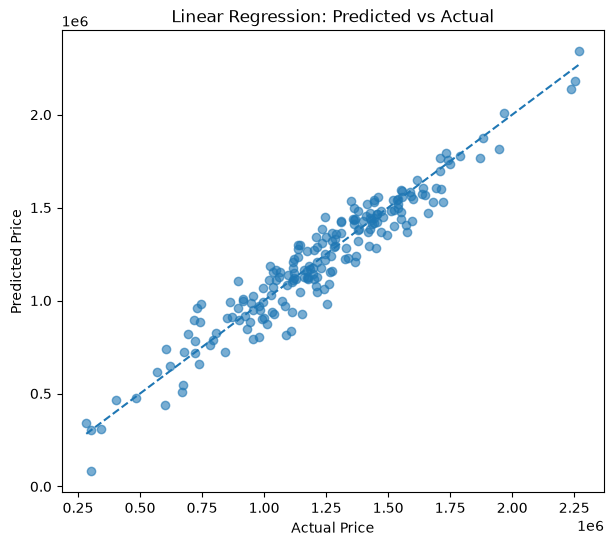

In [25]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, linear_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Predicted vs Actual")

plt.show()

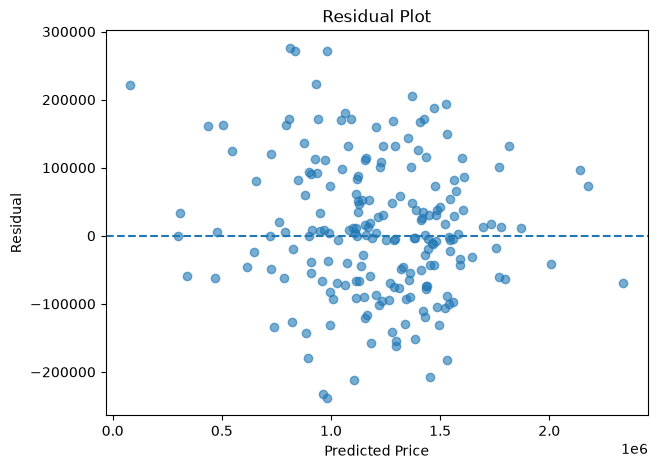

In [26]:
residuals = y_test - linear_pred

plt.figure(figsize=(7, 5))

plt.scatter(linear_pred, residuals, alpha=0.6)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [27]:
final_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

final_coefficients

,Feature,Coefficient
0,Avg. Area Income,21.934054
1,House Age,165890.458627
2,Number of Rooms,122831.101906
3,Number of Bedrooms,-3732.298158
4,Area Population,14.776010


In [28]:
print("Intercept:", linear_model.intercept_)

Intercept: -2643120.5747792516


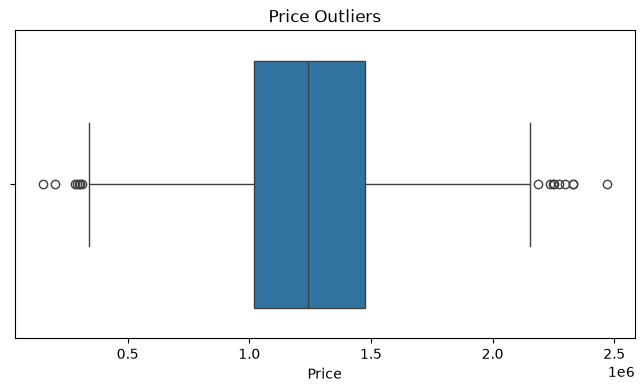

In [29]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Price"])

plt.title("Price Outliers")
plt.xlabel("Price")

plt.show()

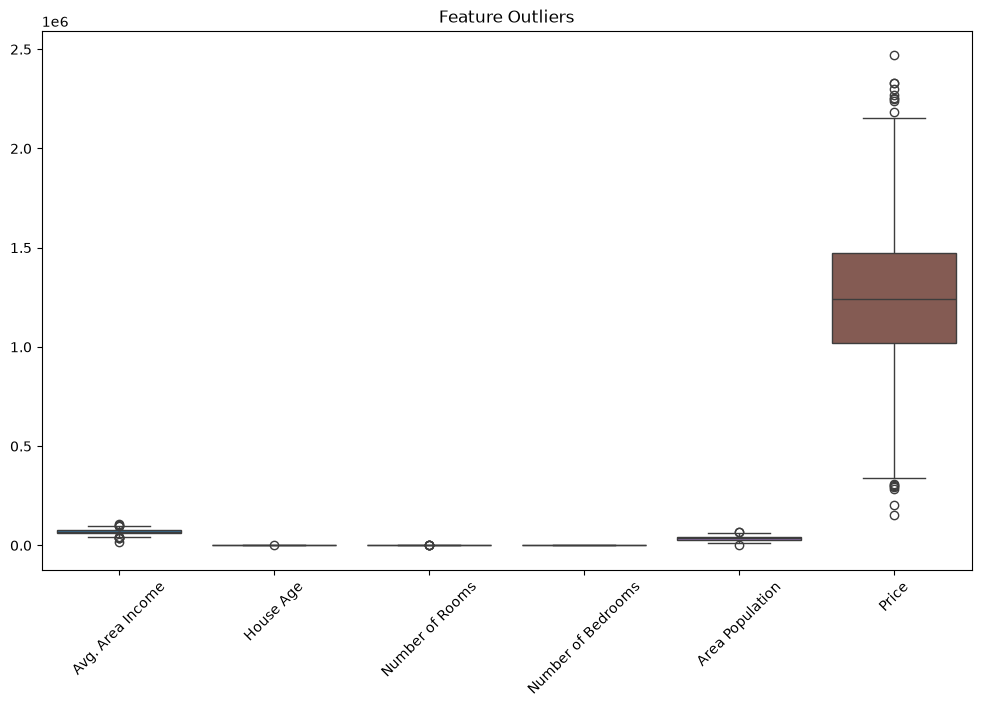

In [30]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Feature Outliers")

plt.show()

In [31]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = ((df < lower) | (df > upper)).any(axis=1)

print("Total rows:", len(df))
print("Outlier rows:", outlier_mask.sum())
print("Clean rows:", (~outlier_mask).sum())

Total rows: 999
Outlier rows: 31
Clean rows: 968


In [32]:
df_clean = df[~outlier_mask].copy()

X_clean = df_clean[features]
y_clean = df_clean["Price"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42
)

clean_model = LinearRegression()

clean_model.fit(X_train_c, y_train_c)

clean_pred = clean_model.predict(X_test_c)

clean_r2 = r2_score(y_test_c, clean_pred)
clean_rmse = np.sqrt(mean_squared_error(y_test_c, clean_pred))

print("Without outliers")
print("----------------")
print("R²  :", round(clean_r2, 4))
print("RMSE:", round(clean_rmse, 2))

Without outliers
----------------
R²  : 0.9006
RMSE: 97688.95


In [33]:
# FINAL MODEL RESULTS

final_model = LinearRegression()

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

final_r2 = r2_score(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("FINAL MODEL")
print("=" * 40)
print("Model      : Linear Regression")
print("Features   :", features)
print("Train size :", len(X_train))
print("Test size  :", len(X_test))
print()
print("Test R²    :", round(final_r2, 4))
print("Test RMSE  :", round(final_rmse, 2))
print("Mean CV R² :", round(cv_scores.mean(), 4))
print("CV Std     :", round(cv_scores.std(), 4))
print()
print("Intercept  :", round(final_model.intercept_, 2))
print()
print("Coefficients:")
for feature, coefficient in zip(features, final_model.coef_):
    print(f"{feature:25} : {coefficient:.4f}")

FINAL MODEL
Model      : Linear Regression
Features   : ['Avg. Area Income', 'House Age', 'Number of Rooms', 'Number of Bedrooms', 'Area Population']
Train size : 799
Test size  : 200

Test R²    : 0.9164
Test RMSE  : 100807.47
Mean CV R² : 0.9171
CV Std     : 0.0056

Intercept  : -2643120.57

Coefficients:
Avg. Area Income          : 21.9341
House Age                 : 165890.4586
Number of Rooms           : 122831.1019
Number of Bedrooms        : -3732.2982
Area Population           : 14.7760


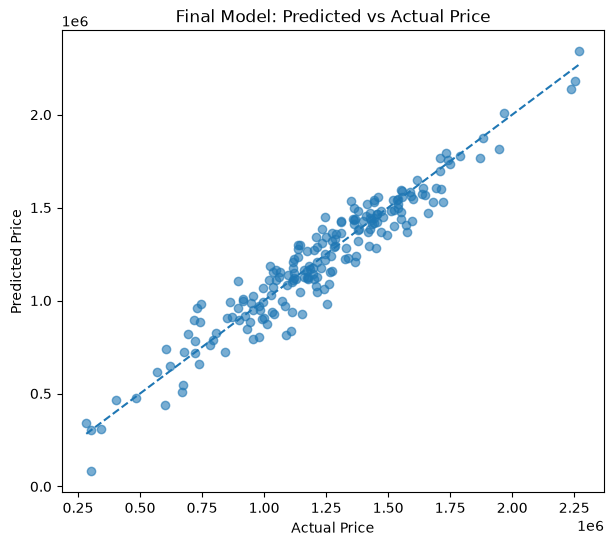

In [34]:
# FINAL PREDICTED VS ACTUAL PLOT

plt.figure(figsize=(7, 6))

plt.scatter(y_test, final_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Final Model: Predicted vs Actual Price")

plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

for seed in [1, 10, 20, 30, 40, 42, 50, 100]:
    
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed
    )

    model_s = LinearRegression()
    model_s.fit(X_train_s, y_train_s)

    pred_s = model_s.predict(X_test_s)

    print(
        f"seed={seed:<3} "
        f"R²={r2_score(y_test_s, pred_s):.4f}"
    )

seed=1   R²=0.9326
seed=10  R²=0.9186
seed=20  R²=0.9233
seed=30  R²=0.9163
seed=40  R²=0.9211
seed=42  R²=0.9164
seed=50  R²=0.9266
seed=100 R²=0.9362
